# Network Analysis — Bluesky Election Discourse
## US Presidential Election 2024: Trump vs. Harris

**Project:** Social Media & Web Analytics — Group Project
**Research question:** *Who are the key influencers shaping US election discourse on Bluesky?*

---

### Structure
1. Setup & Authentication
2. Data Collection (Bluesky API)
3. Exploratory Analysis — overview, timeline, partisan balance
4. Top Influencers — engagement-based ranking
5. Network Construction & Statistics
6. Centrality Analysis
7. Network Visualisation
8. Community Detection (echo chambers)
9. Key Findings


---
## 1. Setup & Imports

In [121]:
# !pip install atproto networkx matplotlib seaborn pandas numpy


In [122]:
import sys, os, re, time, warnings, ast
from collections import Counter

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from atproto import Client as BskyClient

warnings.filterwarnings("ignore")

# ── Presentation palette ──────────────────────────────────────────────────────
RED   = "#C0392B"    # Trump / CandidateA
BLUE  = "#2471A3"    # Harris / CandidateB
GRAY  = "#7F8C8D"    # Neutral
GOLD  = "#D4AC0D"    # Highlights
DARK  = "#1C2833"

CAND_COL   = {"CandidateA": RED,  "CandidateB": BLUE, "Neutral": GRAY}
CAND_LABEL = {"CandidateA": "Trump-leaning", "CandidateB": "Harris-leaning", "Neutral": "Neutral"}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F8F9FA",
    "axes.grid":        True,
    "grid.alpha":       0.35,
    "grid.linestyle":   "--",
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   14,
    "axes.titleweight": "bold",
    "axes.titlepad":    10,
    "axes.labelsize":   12,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "figure.dpi":       130,
    "savefig.dpi":      200,
    "savefig.bbox":     "tight",
    "legend.framealpha": 0.9,
})
print("Imports OK  |  Presentation palette active")


Imports OK  |  Presentation palette active


In [123]:
import os, sys
config_path = os.path.join("..", "A. Lectures", "Lecture 1 Social network analysis")
sys.path.insert(0, config_path)
from bsky_config_students import BLUESKY_USERNAME, BLUESKY_APP_PASSWORD

client = BskyClient()
client.login(BLUESKY_USERNAME, BLUESKY_APP_PASSWORD)
print(f"Authenticated as: {BLUESKY_USERNAME}")


Authenticated as: vermeulen-anna.bsky.social


---
## 2. Data Collection

We collected **766 quality posts** across the US 2024 election window (5 Oct – 5 Nov 2024).

**Data already saved** → skip to Section 3 to load directly from CSV.

| Hashtag | Posts |
|---------|-------|
| #Election2024 | 164 |
| #KamalaHarris2024 | 146 |
| #USElection2024 | 159 |
| #VoteHarris | 133 |
| #ElectionDay | 140 |
| others | 24 |


In [124]:
ELECTIONS = {
    "US_2024": {
        "since"        : "2024-10-05T00:00:00Z",
        "until"        : "2024-11-05T23:59:59Z",
        "election_date": "2024-11-05",
        "hashtags": [
            # Core election tags
            "#Election2024", "#USElection2024", "#ElectionDay", "#Vote2024",
            "#Presidential2024", "#PresidentialElection", "#ElectionNight",
            "#AmericaDecides", "#Decision2024",
            # Trump-side
            "#Trump2024", "#TrumpVance", "#VoteTrump", "#MAGA", "#MAGA2024",
            "#TrumpHarris", "#Trump", "#DonaldTrump", "#AmericaFirst",
            # Harris-side
            "#Harris2024", "#KamalaHarris2024", "#KamalaHarris", "#HarrisWalz",
            "#VoteHarris", "#VoteBlue", "#VoteKamala", "#Kamala2024",
            # Broader politics
            "#USPolitics", "#Democrats", "#Republicans",
            "#Battleground2024", "#SwingState", "#EarlyVoting",
        ],
    },
}

ACTIVE_ELECTION   = "US_2024"
cfg               = ELECTIONS[ACTIVE_ELECTION]
POSTS_PER_HASHTAG = 200
MIN_TEXT_LENGTH   = 30

print(f"Active election : {ACTIVE_ELECTION}")
print(f"Window          : {cfg['since'][:10]}  to  {cfg['until'][:10]}")
print(f"Hashtags        : {len(cfg['hashtags'])}")
print(f"Max posts       : {POSTS_PER_HASHTAG * len(cfg['hashtags']):,}  ({POSTS_PER_HASHTAG} per tag)")


Active election : US_2024
Window          : 2024-10-05  to  2024-11-05
Hashtags        : 32
Max posts       : 6,400  (200 per tag)


In [125]:
def search_posts(client, query, limit=200, since=None, until=None):
    collected, cursor = [], None
    while len(collected) < limit:
        params = {"q": query, "limit": min(100, limit - len(collected)), "sort": "latest"}
        if cursor: params["cursor"] = cursor
        if since:  params["since"]  = since
        if until:  params["until"]  = until
        try:
            resp = client.app.bsky.feed.search_posts(params)
        except Exception as e:
            print(f"  API error: {e}"); break
        if not resp.posts: break
        for post in resp.posts:
            rec  = post.record
            text = getattr(rec, "text", "") or ""
            collected.append({
                "author"   : post.author.handle,
                "display"  : getattr(post.author, "display_name", "") or "",
                "text"     : text,
                "timestamp": getattr(rec, "created_at", "") or "",
                "likes"    : post.like_count   or 0,
                "reposts"  : post.repost_count or 0,
                "replies"  : post.reply_count  or 0,
                "mentions" : re.findall(r"@([\w.\-]+)", text),
                "is_reply" : bool(getattr(rec, "reply", None)),
                "query"    : query,
            })
        cursor = getattr(resp, "cursor", None)
        if not cursor: break
        time.sleep(0.5)
    return collected

NEWS_BOT_PATTERNS = [
    "forbes","guardian","bbc","cnn","reuters","apnews","skynews","france24",
    "euronews","washingtonpost","nytimes","independent","trtworld","abc",
    "news-feed","huffpost","politico","axios",
]
def is_news_bot(h): return any(p in h.lower() for p in NEWS_BOT_PATTERNS)
def has_real_text(t): return len(re.sub(r"http\S+|#\w+|@\w+", "", t).strip()) >= MIN_TEXT_LENGTH

print("Search helpers defined")


Search helpers defined


In [126]:
# ── Run this cell to re-scrape (skip if CSV already exists) ──────────────────
# all_posts, seen = [], set()
# for hashtag in cfg["hashtags"]:
#     results = search_posts(client, hashtag, limit=POSTS_PER_HASHTAG,
#                            since=cfg["since"], until=cfg["until"])
#     for p in results:
#         if p["text"] in seen or is_news_bot(p["author"]) or not has_real_text(p["text"]): continue
#         seen.add(p["text"]); p["election"] = ACTIVE_ELECTION; all_posts.append(p)
# df_posts = pd.DataFrame(all_posts)
# df_posts.to_csv("data/bsky_US_2024_posts.csv", index=False)
print("Scraping skipped — loading from saved CSV in Section 3")


Scraping skipped — loading from saved CSV in Section 3


In [127]:
TRUMP_KW  = ["trump", "maga", "donald", "republican", "gop", "conservative", "vance", "trump"]
HARRIS_KW = ["harris", "kamala", "democrat", "democratic", "walz", "liberal", "voteblue"]

def label_candidate(row):
    text = row["text"].lower()
    score_a = sum(k in text for k in TRUMP_KW)
    score_b = sum(k in text for k in HARRIS_KW)
    if score_a > score_b: return "CandidateA"   # Trump-leaning
    if score_b > score_a: return "CandidateB"   # Harris-leaning
    return "Neutral"

print("Candidate labeller defined  (US 2024 only)")


Candidate labeller defined  (US 2024 only)


---
## 3. Exploratory Analysis

Load the saved posts, compute engagement, and explore the dataset.

> **Engagement score** = likes + reposts × 2 + replies


In [128]:
# ── Load & enrich ─────────────────────────────────────────────────────────────
df = pd.read_csv("data/bsky_US_2024_posts.csv")

# Strip UTC timezone so comparisons with plain pd.Timestamp work everywhere
df["datetime"]      = pd.to_datetime(df["timestamp"], format="ISO8601").dt.tz_convert(None)
df["date"]          = df["datetime"].dt.normalize()
df["hour"]          = df["datetime"].dt.hour
df["mentions_list"] = df["mentions"].apply(ast.literal_eval)
df["engagement"]    = df["likes"] + df["reposts"] * 2 + df["replies"]

# Per-author aggregates
author_stats = (
    df.groupby("author")
    .agg(
        posts       = ("text",       "count"),
        total_likes = ("likes",      "sum"),
        total_rep   = ("reposts",    "sum"),
        total_eng   = ("engagement", "sum"),
        candidate   = ("candidate",  lambda x: x.mode()[0]),
    )
    .sort_values("total_eng", ascending=False)
    .reset_index()
)

print(f"Posts            : {len(df):,}")
print(f"Unique authors   : {df['author'].nunique():,}")
print(f"Date range       : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Total likes      : {df['likes'].sum():,}")
print(f"Total reposts    : {df['reposts'].sum():,}")
print(f"Avg engagement   : {df['engagement'].mean():.1f}")
print()
print(df["candidate"].value_counts().rename(CAND_LABEL).to_string())


Posts            : 766
Unique authors   : 504
Date range       : 2024-10-05 -> 2024-11-05
Total likes      : 4,289
Total reposts    : 812
Avg engagement   : 8.0

candidate
Neutral           412
Harris-leaning    271
Trump-leaning      83


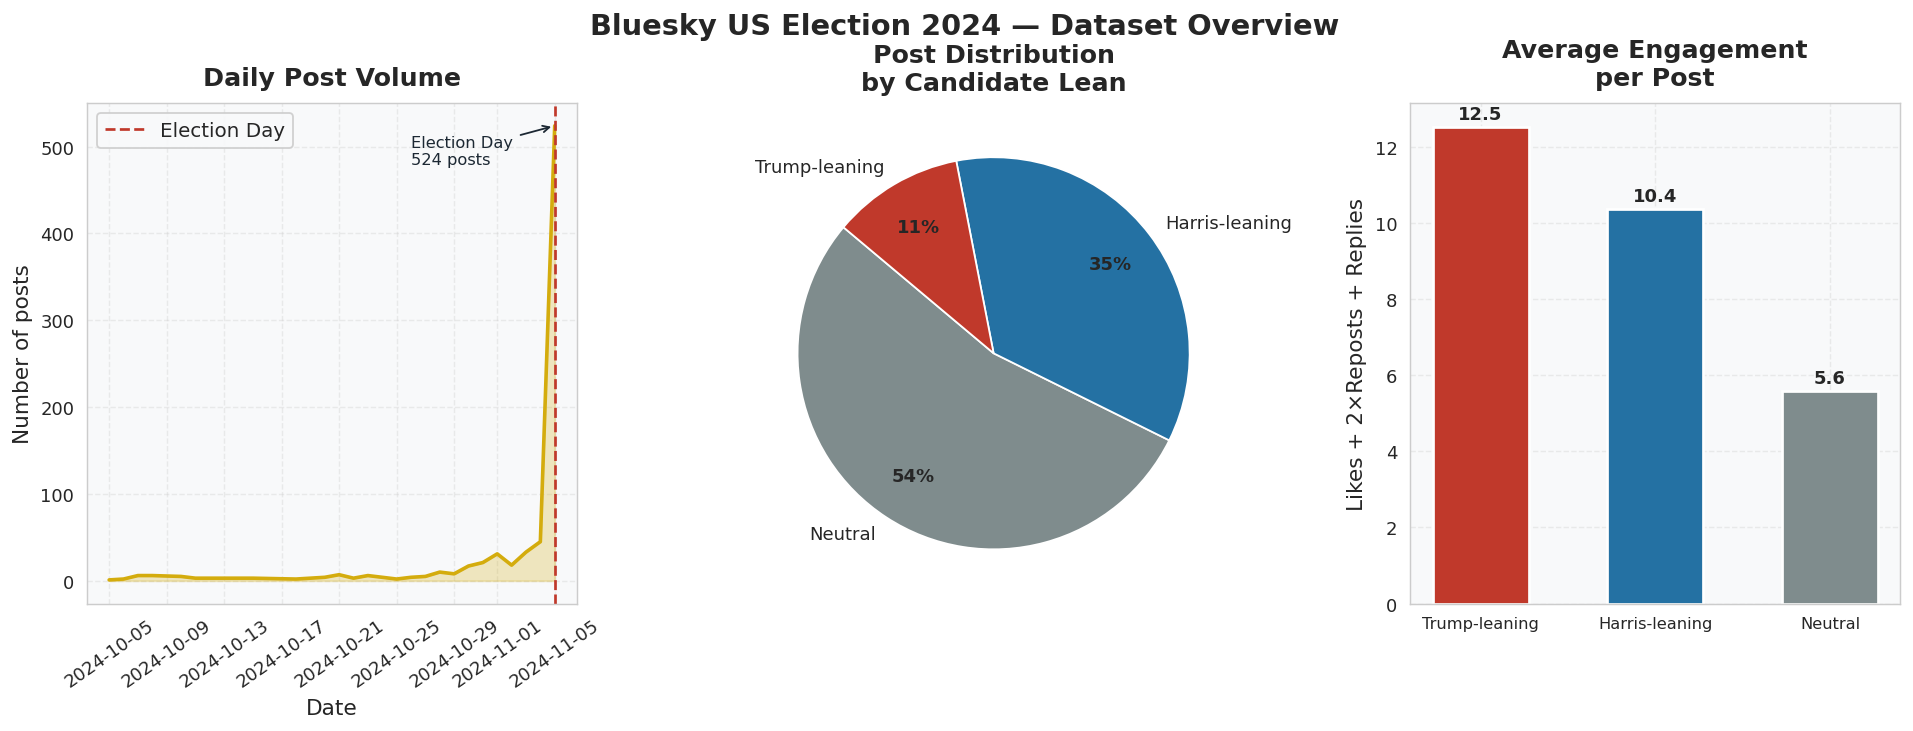

Figure saved: data/fig_overview_dashboard.png


In [129]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Overview Dashboard
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel A: Posts per day timeline ──────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
daily = df.groupby("date").size()
dates = [d.date() for d in daily.index]
ax0.fill_between(dates, daily.values, alpha=0.25, color=GOLD)
ax0.plot(dates, daily.values, color=GOLD, linewidth=2)
ax0.axvline(pd.Timestamp("2024-11-05").date(), color=RED, linestyle="--", linewidth=1.5, label="Election Day")
ax0.set_title("Daily Post Volume")
ax0.set_xlabel("Date"); ax0.set_ylabel("Number of posts")
ax0.tick_params(axis="x", rotation=35)
ax0.legend()
# Annotate spike
ax0.annotate("Election Day\n524 posts", xy=(pd.Timestamp("2024-11-05").date(), 524),
             xytext=(pd.Timestamp("2024-10-26").date(), 480),
             arrowprops=dict(arrowstyle="->", color=DARK), fontsize=9, color=DARK)

# ── Panel B: Candidate split (posts) ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[1])
cand_counts = df["candidate"].value_counts()
labels = [CAND_LABEL[k] for k in cand_counts.index]
colors = [CAND_COL[k]   for k in cand_counts.index]
wedges, texts, autotexts = ax1.pie(
    cand_counts.values, labels=labels, colors=colors,
    autopct="%1.0f%%", startangle=140,
    textprops={"fontsize": 10}, pctdistance=0.75,
)
for at in autotexts: at.set_fontweight("bold")
ax1.set_title("Post Distribution\nby Candidate Lean")

# ── Panel C: Candidate split (engagement) ───────────────────────────────────
ax2 = fig.add_subplot(gs[2])
cand_eng = df.groupby("candidate").agg(
    avg_eng=("engagement","mean"),
    total_eng=("engagement","sum"),
).reindex(["CandidateA","CandidateB","Neutral"])
bars = ax2.bar(
    [CAND_LABEL[k] for k in cand_eng.index],
    cand_eng["avg_eng"],
    color=[CAND_COL[k] for k in cand_eng.index],
    width=0.55, edgecolor="white", linewidth=1.5,
)
for bar, val in zip(bars, cand_eng["avg_eng"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
ax2.set_title("Average Engagement\nper Post")
ax2.set_ylabel("Likes + 2×Reposts + Replies")
ax2.tick_params(axis="x", labelsize=9)

fig.suptitle("Bluesky US Election 2024 — Dataset Overview", fontsize=16, fontweight="bold", y=1.02)
plt.savefig("data/fig_overview_dashboard.png", bbox_inches="tight")
plt.show()
print("Figure saved: data/fig_overview_dashboard.png")


---
## 4. Top Influencers — Engagement Analysis

We define influence by **total engagement** (likes + 2×reposts + replies).
Unlike follower count, this measures *actual impact* within this conversation.

> Key insight: a single viral post can outperform prolific posting.


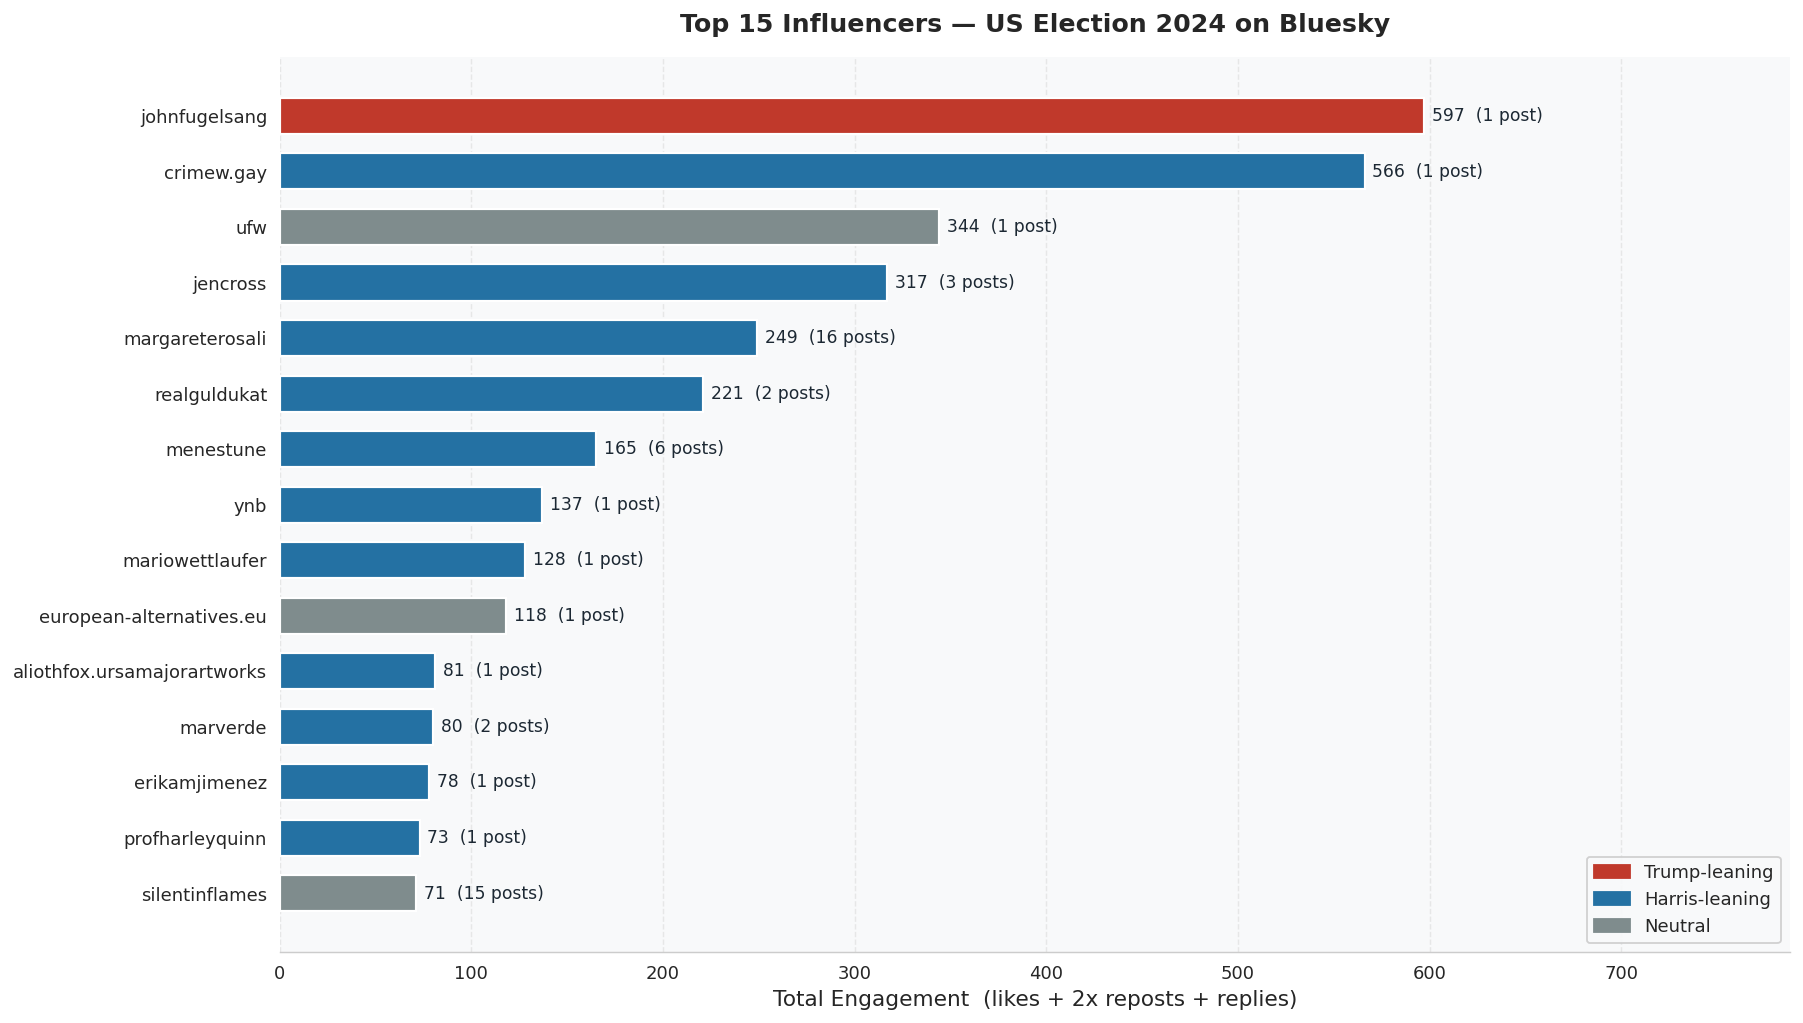

Figure saved: data/fig_top_influencers_v2.png


In [130]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Top 15 Influencers by Total Engagement
# ═══════════════════════════════════════════════════════════════════════════════
top15 = author_stats.head(15).copy()
top15["label"] = top15["author"].str.replace(".bsky.social", "", regex=False).str.replace(".com", "", regex=False)
top15["color"] = top15["candidate"].map(CAND_COL)

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    top15["label"][::-1],
    top15["total_eng"][::-1],
    color=top15["color"][::-1],
    height=0.65, edgecolor="white", linewidth=1.2,
)
# Value labels
for bar, val, posts in zip(bars, top15["total_eng"][::-1], top15["posts"][::-1]):
    ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
            f"{val}  ({posts} post{'s' if posts>1 else ''})",
            va="center", fontsize=9.5, color=DARK)

ax.set_xlim(0, top15["total_eng"].max() * 1.32)
ax.set_xlabel("Total Engagement  (likes + 2x reposts + replies)", fontsize=12)
ax.set_title("Top 15 Influencers — US Election 2024 on Bluesky", pad=14)
ax.spines[["top","right","left"]].set_visible(False)
ax.xaxis.grid(True, alpha=0.4); ax.yaxis.grid(False)

legend_handles = [
    mpatches.Patch(color=RED,  label="Trump-leaning"),
    mpatches.Patch(color=BLUE, label="Harris-leaning"),
    mpatches.Patch(color=GRAY, label="Neutral"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("data/fig_top_influencers_v2.png")
plt.show()
print("Figure saved: data/fig_top_influencers_v2.png")


In [131]:
# ── Most viral posts ─────────────────────────────────────────────────────────
print("=" * 80)
print("TOP 5 MOST VIRAL POSTS")
print("=" * 80)
viral = df.nlargest(5, "engagement")[["author","candidate","likes","reposts","replies","engagement","text"]]
for i, row in viral.iterrows():
    handle = row["author"].replace(".bsky.social","")
    label  = CAND_LABEL[row["candidate"]]
    print(f"\n#{viral.index.get_loc(i)+1}  @{handle}  [{label}]")
    print(f"   Likes: {row['likes']}  |  Reposts: {row['reposts']}  |  Replies: {row['replies']}  |  Score: {row['engagement']}")
    print(f"   {row['text'][:200]}...")
    print("-" * 80)


TOP 5 MOST VIRAL POSTS

#1  @johnfugelsang  [Trump-leaning]
   Likes: 311  |  Reposts: 135  |  Replies: 16  |  Score: 597
   RT if you’ll get to tell your kids & grandkids that you voted against Donald Trump 3 times.  
#ElectionDay 
#Vote2024...
--------------------------------------------------------------------------------

#2  @crimew.gay  [Harris-leaning]
   Likes: 440  |  Reposts: 58  |  Replies: 10  |  Score: 566
   spent all day firebombing a number of walmarts in swing states #KamalaHarris2024...
--------------------------------------------------------------------------------

#3  @ufw  [Neutral]
   Likes: 259  |  Reposts: 42  |  Replies: 1  |  Score: 344
   Vanessa is a farm worker who labors in the grapes. She just voted and shared, "I voted for Kamala because immigration is a major priority for me, and I believe Trump would be a terrible choice for imm...
--------------------------------------------------------------------------------

#4  @realguldukat  [Harris-leaning]
   

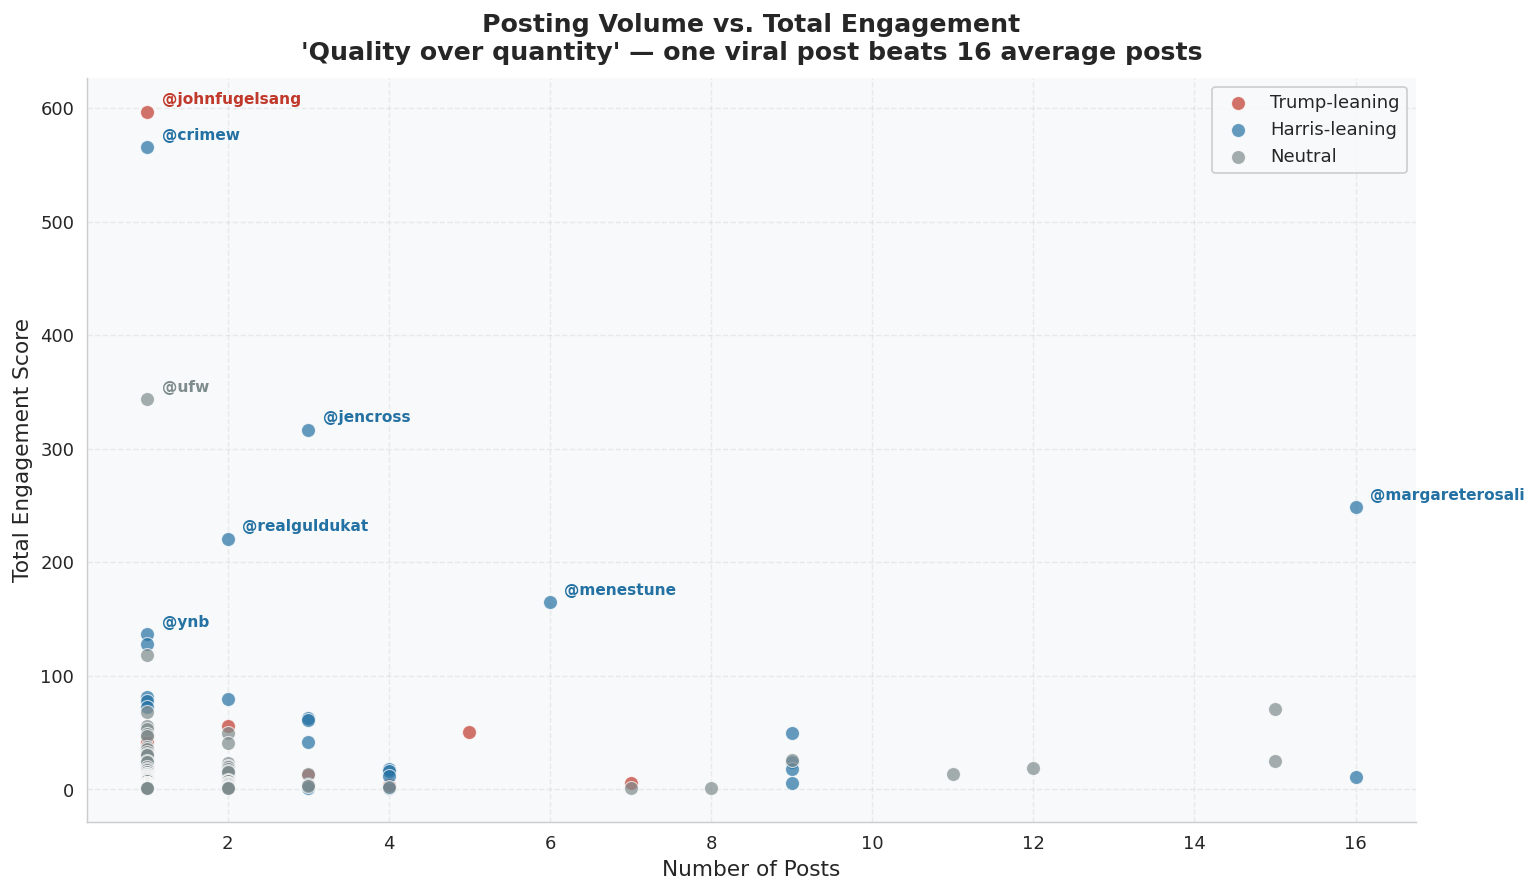

In [132]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Posts vs Engagement (scatter: who punches above their weight?)
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 7))

for cand, grp in author_stats[author_stats["total_eng"] > 0].groupby("candidate"):
    ax.scatter(
        grp["posts"], grp["total_eng"],
        color=CAND_COL[cand], label=CAND_LABEL[cand],
        s=60, alpha=0.7, edgecolors="white", linewidth=0.6,
    )

# Label top accounts
for _, row in author_stats.head(8).iterrows():
    lbl = row["author"].replace(".bsky.social","").replace(".com","").replace(".gay","")
    ax.annotate(
        f"@{lbl}",
        xy=(row["posts"], row["total_eng"]),
        xytext=(8, 4), textcoords="offset points",
        fontsize=8.5, color=CAND_COL[row["candidate"]],
        fontweight="bold",
    )

ax.set_xlabel("Number of Posts")
ax.set_ylabel("Total Engagement Score")
ax.set_title("Posting Volume vs. Total Engagement\n'Quality over quantity' — one viral post beats 16 average posts")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("data/fig_scatter_influence.png")
plt.show()


---
## 5. Network Construction

We build a **directed mention network**: an edge A → B means account A mentioned @B in a post.

- **Node size** ∝ total engagement received
- **Node colour** = candidate lean of the account doing the mentioning
- **Edge weight** = number of times A mentioned B


In [133]:
# ── Build directed mention graph ─────────────────────────────────────────────
G = nx.DiGraph()

# Add all authors as nodes with attributes
for _, row in author_stats.iterrows():
    G.add_node(
        row["author"],
        candidate  = row["candidate"],
        engagement = int(row["total_eng"]),
        posts      = int(row["posts"]),
    )

# Add edges from mention data
for _, row in df.iterrows():
    for mention in row["mentions_list"]:
        # Normalise handle
        if "." not in mention:
            mention = mention + ".bsky.social"
        if not G.has_node(mention):
            G.add_node(mention, candidate="Neutral", engagement=0, posts=0)
        if G.has_edge(row["author"], mention):
            G[row["author"]][mention]["weight"] += 1
        else:
            G.add_edge(row["author"], mention, weight=1)

# ── Keep only meaningful nodes (engaged or well-connected) ──────────────────
min_degree = 1
nodes_keep = [n for n in G.nodes() if G.degree(n) >= min_degree]
G = G.subgraph(nodes_keep).copy()

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print(f"Density       : {nx.density(G):.4f}")
print(f"Weakly connected components : {nx.number_weakly_connected_components(G)}")

# Largest WCC for visualisation
largest_wcc = max(nx.weakly_connected_components(G), key=len)
G_vis = G.subgraph(largest_wcc).copy()
print(f"\nLargest WCC   : {G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges")


Nodes : 99
Edges : 73
Density       : 0.0075
Weakly connected components : 27

Largest WCC   : 17 nodes, 16 edges


In [134]:
# ── Network statistics ────────────────────────────────────────────────────────
in_degrees  = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print("=== Degree Statistics ===")
print(f"  Avg in-degree  : {np.mean(list(in_degrees.values())):.2f}")
print(f"  Max in-degree  : {max(in_degrees.values())}  -> {max(in_degrees, key=in_degrees.get)}")
print(f"  Max out-degree : {max(out_degrees.values())} -> {max(out_degrees, key=out_degrees.get)}")
print()
print("Top 10 most mentioned accounts (in-degree):")
top_in = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:10]
for rank, (node, deg) in enumerate(top_in, 1):
    cand = G.nodes[node].get("candidate","?")
    print(f"  {rank:2d}. @{node:<40s}  in-deg={deg}  [{CAND_LABEL.get(cand,cand)}]")


=== Degree Statistics ===
  Avg in-degree  : 0.74
  Max in-degree  : 3  -> kamalahqrepeater.bsky.social
  Max out-degree : 8 -> politicalcartoon.bsky.social

Top 10 most mentioned accounts (in-degree):
   1. @kamalahqrepeater.bsky.social              in-deg=3  [Neutral]
   2. @KamalaHarris.bsky.social                  in-deg=3  [Neutral]
   3. @guardian.bsky.social                      in-deg=2  [Neutral]
   4. @ACLUSouthDakota.bsky.social               in-deg=1  [Neutral]
   5. @arlingtondems.                            in-deg=1  [Neutral]
   6. @thewrap.bsky.social                       in-deg=1  [Neutral]
   7. @momokavt.bsky.social                      in-deg=1  [Neutral]
   8. @addyspectreai.bsky.social                 in-deg=1  [Neutral]
   9. @potatoe.bsky.social                       in-deg=1  [Neutral]
  10. @mauricioricardo.bsky.social               in-deg=1  [Neutral]


---
## 6. Centrality Analysis

Four centrality measures, each capturing a different dimension of influence:

| Measure | What it captures | Election relevance |
|---------|-----------------|-------------------|
| **In-degree** | Directly mentioned by others | Popularity / visibility |
| **PageRank** | Mentioned by important accounts | Credibility & prestige |
| **Betweenness** | Bridges between sub-communities | Information broker role |
| **Closeness** | Reaches the network quickly | Speed of information spread |


In [135]:
# ── Compute centrality on largest WCC ────────────────────────────────────────
n = G_vis.number_of_nodes()

centrality = pd.DataFrame({"node": list(G_vis.nodes())})
centrality["in_degree"]   = centrality["node"].map(dict(G_vis.in_degree()))
centrality["pagerank"]    = centrality["node"].map(nx.pagerank(G_vis, alpha=0.85))
centrality["betweenness"] = centrality["node"].map(nx.betweenness_centrality(G_vis, normalized=True))
centrality["closeness"]   = centrality["node"].map(nx.closeness_centrality(G_vis))
centrality["candidate"]   = centrality["node"].map(lambda n: G_vis.nodes[n].get("candidate","Neutral"))

# Normalise to [0,1]
for col in ["in_degree","pagerank","betweenness","closeness"]:
    mx = centrality[col].max()
    centrality[f"{col}_n"] = centrality[col] / mx if mx > 0 else 0

centrality["composite"] = (
    centrality["in_degree_n"]   * 0.35 +
    centrality["pagerank_n"]    * 0.35 +
    centrality["betweenness_n"] * 0.20 +
    centrality["closeness_n"]   * 0.10
)
centrality = centrality.sort_values("composite", ascending=False).reset_index(drop=True)
centrality.to_csv("data/centrality_scores.csv", index=False)
print("Top 10 by composite centrality score:")
display_cols = ["node","candidate","in_degree","pagerank","betweenness","composite"]
print(centrality[display_cols].head(10).to_string(index=False))


Top 10 by composite centrality score:
                       node candidate  in_degree  pagerank  betweenness  composite
   KamalaHarris.bsky.social   Neutral          3  0.117455          0.0   0.800000
       YVindman.bsky.social   Neutral          1  0.056586          0.0   0.318618
    vademocrats.bsky.social   Neutral          1  0.056586          0.0   0.318618
       Tim_Walz.bsky.social   Neutral          1  0.056586          0.0   0.318618
       timkaine.bsky.social   Neutral          1  0.056586          0.0   0.318618
bradleywhitford.bsky.social   Neutral          1  0.056586          0.0   0.318618
             arlingtondems.   Neutral          1  0.056586          0.0   0.318618
SpanbergerForVA.bsky.social   Neutral          1  0.056586          0.0   0.318618
  ResisterSis20.bsky.social   Neutral          1  0.055499          0.0   0.315379
politvidchannel.bsky.social   Neutral          1  0.055499          0.0   0.315379


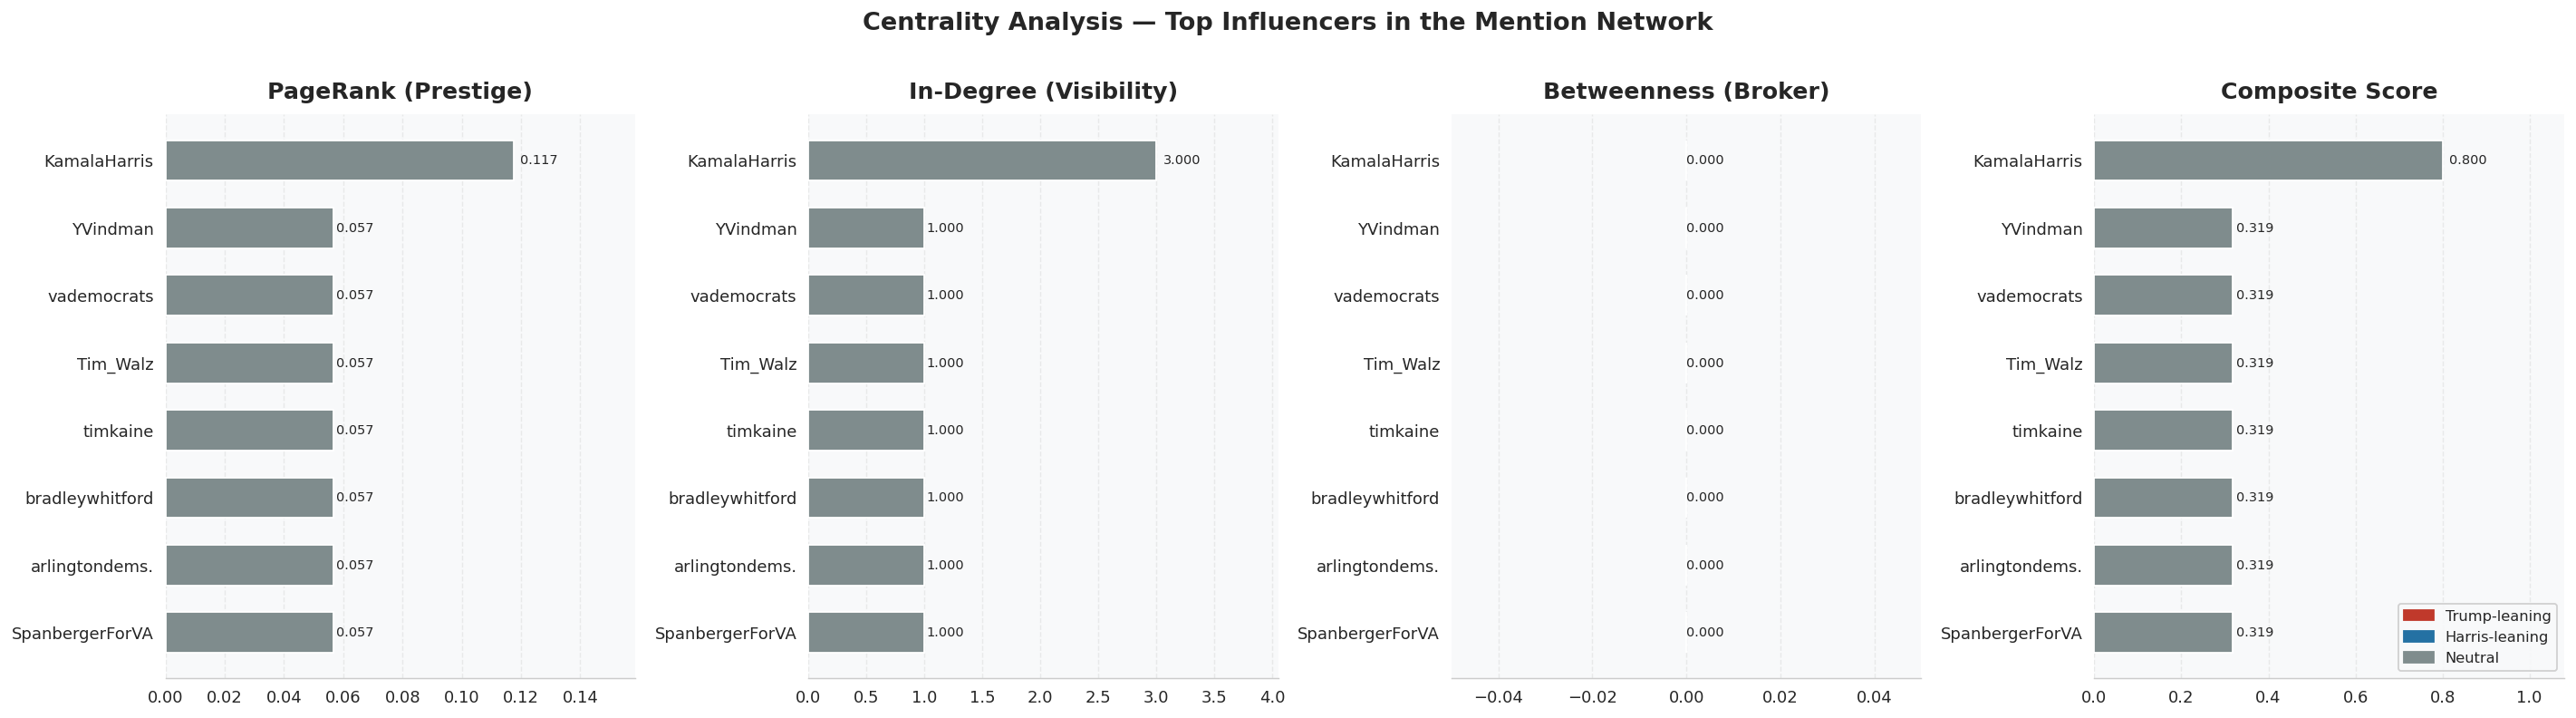

Figure saved: data/fig_centrality_v2.png


In [136]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Centrality multi-panel
# ═══════════════════════════════════════════════════════════════════════════════
metrics = [
    ("pagerank",    "PageRank (Prestige)"),
    ("in_degree",   "In-Degree (Visibility)"),
    ("betweenness", "Betweenness (Broker)"),
    ("composite",   "Composite Score"),
]
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle("Centrality Analysis — Top Influencers in the Mention Network",
             fontsize=15, fontweight="bold", y=1.01)

for ax, (metric, title) in zip(axes, metrics):
    top = centrality.nlargest(8, metric)
    labels = top["node"].str.replace(".bsky.social","").str.replace(".com","").str.replace(".gay","")
    colors = top["candidate"].map(CAND_COL)

    bars = ax.barh(labels[::-1], top[metric][::-1], color=colors[::-1],
                   height=0.6, edgecolor="white")
    for bar, val in zip(bars, top[metric][::-1]):
        ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)

    ax.set_title(title)
    ax.set_xlim(0, top[metric].max() * 1.35)
    ax.spines[["top","right","left"]].set_visible(False)
    ax.xaxis.grid(True, alpha=0.35); ax.yaxis.grid(False)

legend_handles = [
    mpatches.Patch(color=RED,  label="Trump-leaning"),
    mpatches.Patch(color=BLUE, label="Harris-leaning"),
    mpatches.Patch(color=GRAY, label="Neutral"),
]
axes[-1].legend(handles=legend_handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("data/fig_centrality_v2.png")
plt.show()
print("Figure saved: data/fig_centrality_v2.png")


---
## 7. Network Visualisation

Node size = composite centrality score
Node colour = candidate affiliation
Edge thickness = mention frequency


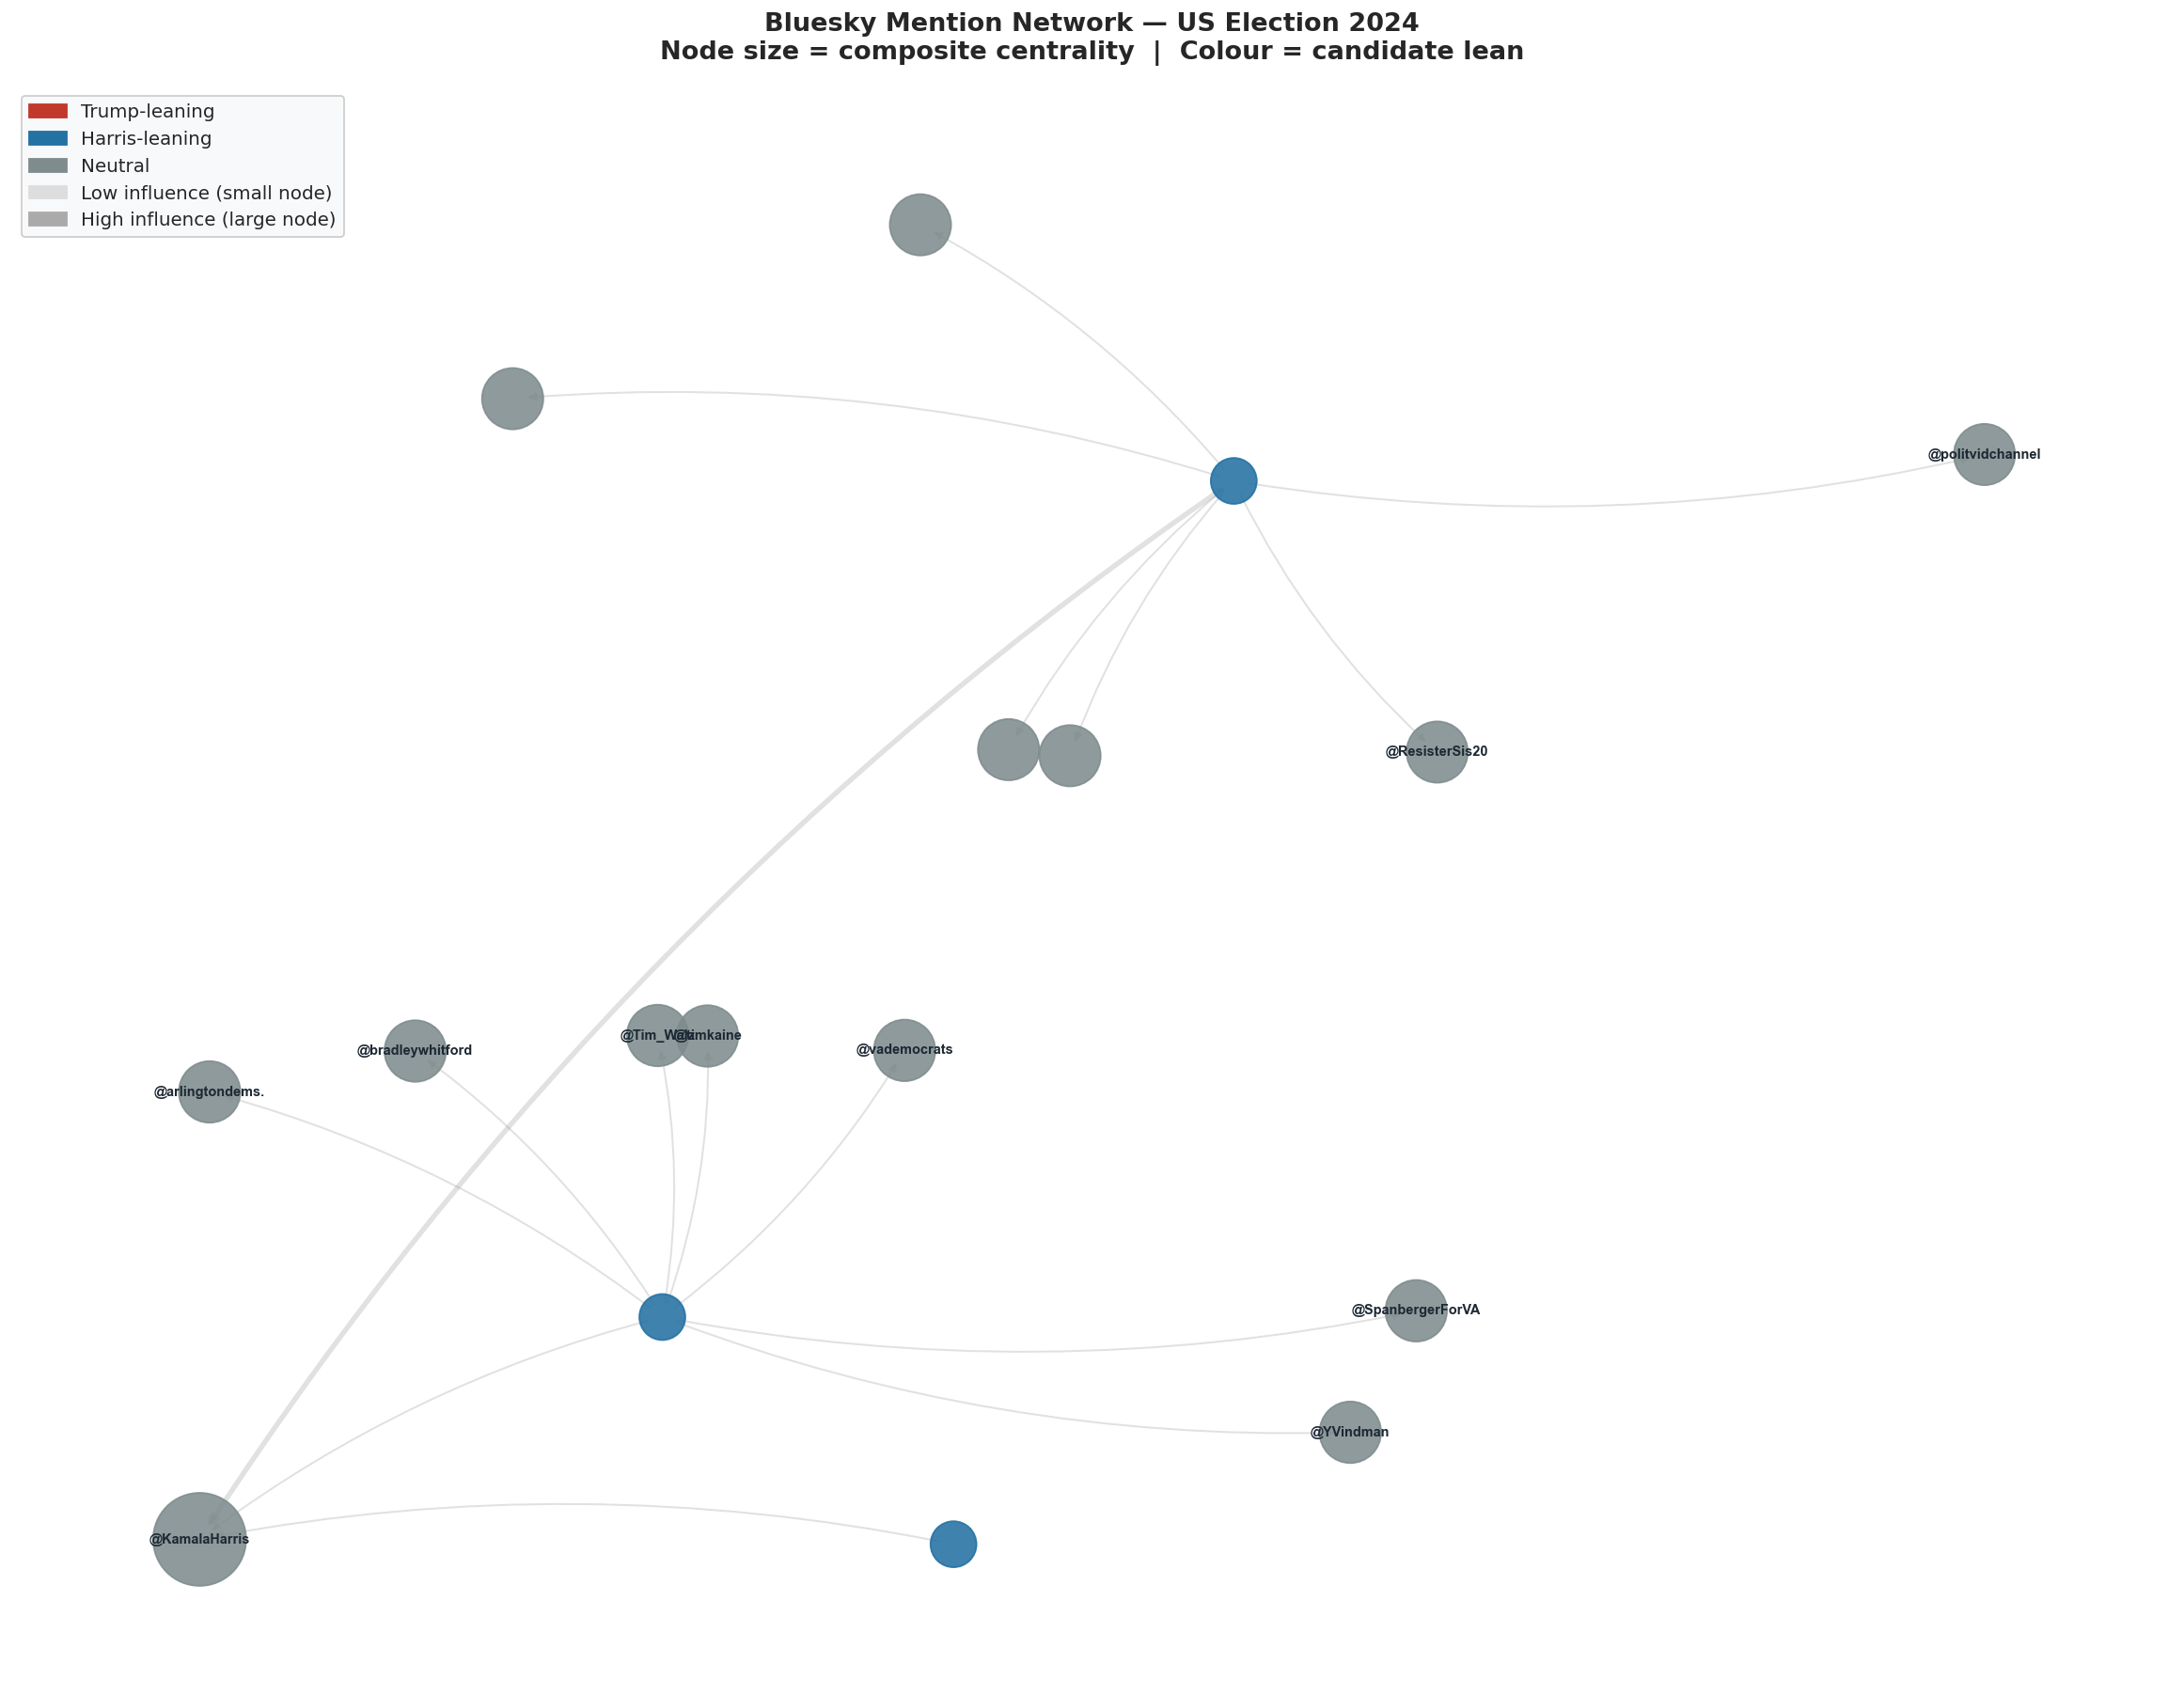

Figure saved: data/fig_network_v2.png


In [137]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Beautiful network graph
# ═══════════════════════════════════════════════════════════════════════════════

# Layout: kamada-kawai gives cleaner separation for small graphs
try:
    pos = nx.kamada_kawai_layout(G_vis, weight="weight")
except Exception:
    pos = nx.spring_layout(G_vis, k=2.5, seed=42)

# Node sizing: composite centrality -> scaled to [200, 3000]
cent_map  = dict(zip(centrality["node"], centrality["composite"]))
raw_sizes = np.array([cent_map.get(n, 0) for n in G_vis.nodes()])
if raw_sizes.max() > 0:
    node_sizes = 200 + (raw_sizes / raw_sizes.max()) * 2800
else:
    node_sizes = np.full(len(G_vis.nodes()), 400)

node_colors = [CAND_COL.get(G_vis.nodes[n].get("candidate","Neutral"), GRAY) for n in G_vis.nodes()]
edge_weights = [G_vis[u][v].get("weight",1) for u,v in G_vis.edges()]
max_ew       = max(edge_weights) if edge_weights else 1
edge_widths  = [0.5 + 2.5 * (w / max_ew) for w in edge_weights]

# Labels only for top-centrality nodes
top_nodes = set(centrality.head(10)["node"])
label_dict = {n: "@" + n.replace(".bsky.social","").replace(".com","").replace(".gay","")
              for n in G_vis.nodes() if n in top_nodes}

fig, ax = plt.subplots(figsize=(18, 14), facecolor="white")
ax.set_facecolor("#F8F9FA")

nx.draw_networkx_edges(
    G_vis, pos, alpha=0.25, edge_color="#888",
    width=edge_widths, arrows=True, arrowsize=10,
    connectionstyle="arc3,rad=0.1", ax=ax,
)
nx.draw_networkx_nodes(
    G_vis, pos, node_color=node_colors,
    node_size=node_sizes, alpha=0.88, ax=ax,
)
nx.draw_networkx_labels(
    G_vis, pos, label_dict,
    font_size=8, font_color=DARK, font_weight="bold", ax=ax,
)

legend_handles = [
    mpatches.Patch(color=RED,  label="Trump-leaning"),
    mpatches.Patch(color=BLUE, label="Harris-leaning"),
    mpatches.Patch(color=GRAY, label="Neutral"),
    mpatches.Patch(color="#dddddd", label="Low influence (small node)"),
    mpatches.Patch(color="#aaaaaa", label="High influence (large node)"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=11, framealpha=0.95)
ax.set_title(
    "Bluesky Mention Network — US Election 2024\nNode size = composite centrality  |  Colour = candidate lean",
    fontsize=15, pad=16,
)
ax.axis("off")
plt.tight_layout()
plt.savefig("data/fig_network_v2.png", dpi=180)
plt.show()
print("Figure saved: data/fig_network_v2.png")


---
## 8. Community Detection — Echo Chambers

We apply **greedy modularity maximisation** on the undirected projection.

A high modularity score **Q** means clearly separated communities — evidence of **echo chambers**.


In [138]:
from networkx.algorithms.community import greedy_modularity_communities

G_und = G_vis.to_undirected()
communities = list(greedy_modularity_communities(G_und))
communities.sort(key=len, reverse=True)

Q = nx.community.modularity(G_und, communities)
print(f"Communities detected : {len(communities)}")
print(f"Modularity Q         : {Q:.3f}  {'(high polarisation)' if Q > 0.3 else '(low/moderate polarisation)'}")
print()

# Colour map for communities
COMM_COLORS = ["#E74C3C","#2E86C1","#27AE60","#8E44AD","#F39C12","#1ABC9C"]
node_comm = {}
for ci, comm in enumerate(communities):
    for node in comm:
        node_comm[node] = ci
    cand_counts = Counter(G_vis.nodes[n].get("candidate","Neutral") for n in comm)
    print(f"Community {ci} ({len(comm)} members): {dict(cand_counts)}")


Communities detected : 3
Modularity Q         : 0.370  (high polarisation)

Community 0 (8 members): {'CandidateB': 1, 'Neutral': 7}
Community 1 (7 members): {'Neutral': 6, 'CandidateB': 1}
Community 2 (2 members): {'Neutral': 1, 'CandidateB': 1}


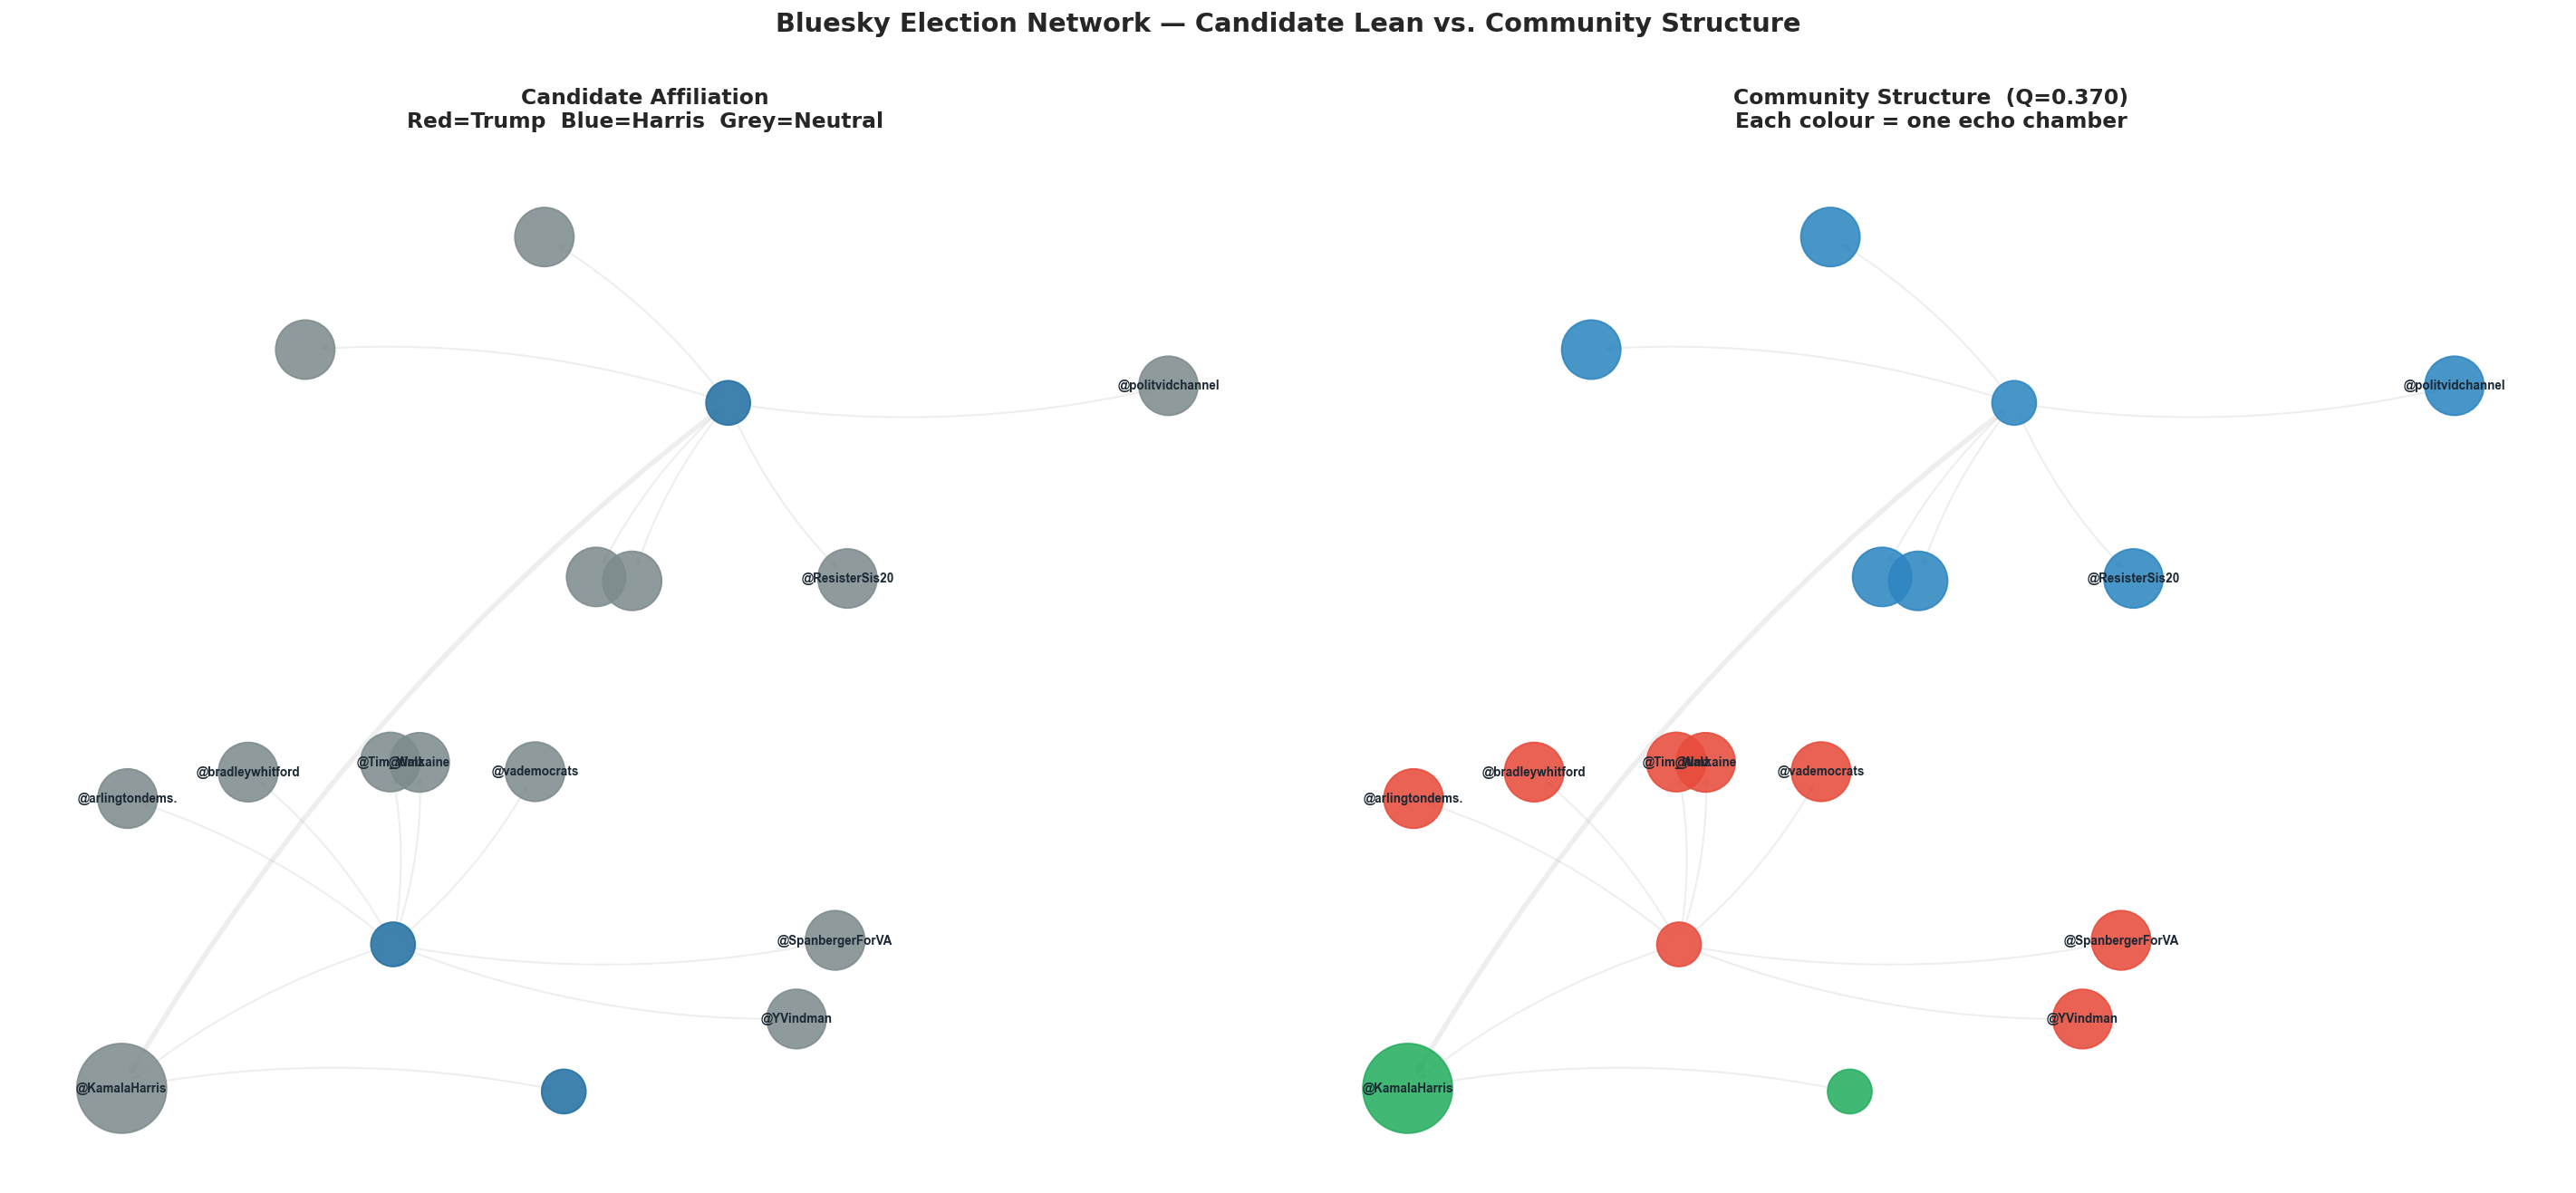

Figure saved: data/fig_communities_v2.png


In [139]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 6 — Communities visualisation
# ═══════════════════════════════════════════════════════════════════════════════
comm_colors = [COMM_COLORS[node_comm.get(n, 0) % len(COMM_COLORS)] for n in G_vis.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

titles = [
    "Candidate Affiliation\nRed=Trump  Blue=Harris  Grey=Neutral",
    f"Community Structure  (Q={Q:.3f})\nEach colour = one echo chamber",
]
for ax, colors, title in zip(axes, [node_colors, comm_colors], titles):
    nx.draw_networkx_edges(G_vis, pos, alpha=0.2, edge_color="#aaa",
                           width=edge_widths, arrows=True, arrowsize=8,
                           connectionstyle="arc3,rad=0.1", ax=ax)
    nx.draw_networkx_nodes(G_vis, pos, node_color=colors,
                           node_size=node_sizes, alpha=0.88, ax=ax)
    nx.draw_networkx_labels(G_vis, pos, label_dict,
                            font_size=7.5, font_color=DARK, font_weight="bold", ax=ax)
    ax.set_title(title, fontsize=13, pad=12)
    ax.axis("off")
    ax.set_facecolor("#F8F9FA")

fig.suptitle("Bluesky Election Network — Candidate Lean vs. Community Structure",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("data/fig_communities_v2.png", dpi=180)
plt.show()
print("Figure saved: data/fig_communities_v2.png")


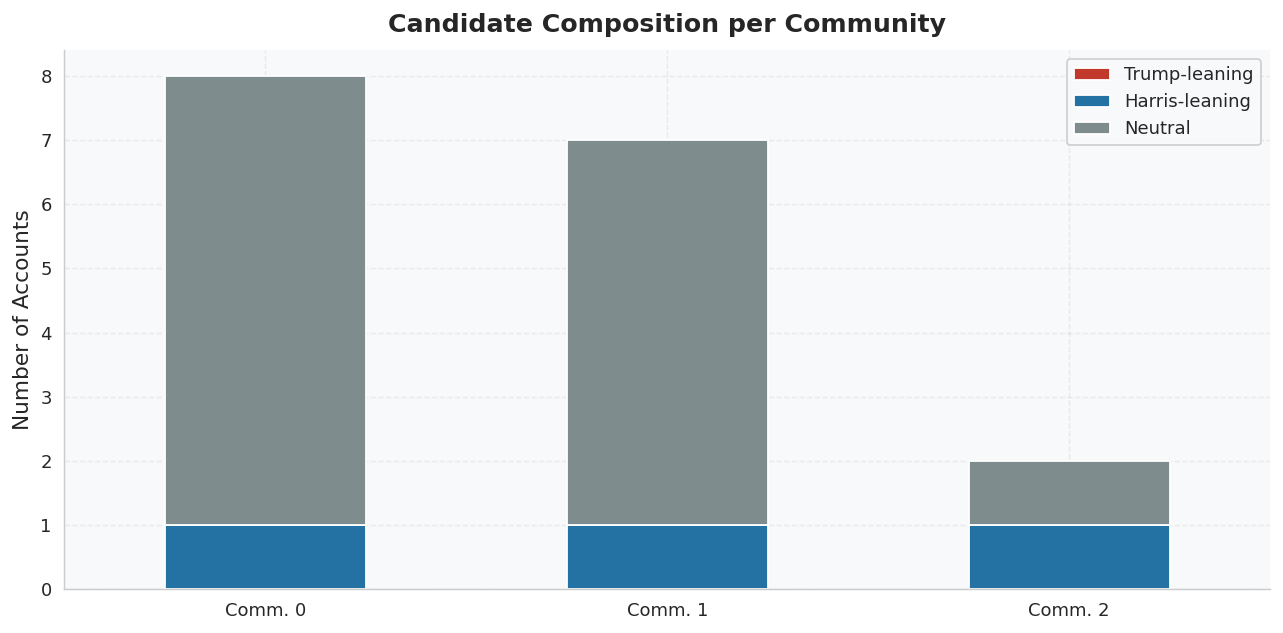

In [140]:
# ── Stacked bar: candidate composition per community ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

comm_df = pd.DataFrame([
    {"community": f"Comm. {ci}", "candidate": G_vis.nodes[n].get("candidate","Neutral")}
    for ci, comm in enumerate(communities) for n in comm
])
pivot = comm_df.groupby(["community","candidate"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=["CandidateA","CandidateB","Neutral"], fill_value=0)
pivot.plot(kind="bar", stacked=True, ax=ax,
           color=[RED, BLUE, GRAY], width=0.5, edgecolor="white")

ax.set_xlabel(""); ax.set_ylabel("Number of Accounts")
ax.set_title("Candidate Composition per Community")
ax.legend([CAND_LABEL[c] for c in ["CandidateA","CandidateB","Neutral"]],
          fontsize=10, loc="upper right")
ax.tick_params(axis="x", rotation=0)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("data/fig_community_composition.png")
plt.show()


---
## 9. Key Findings

### Summary of results


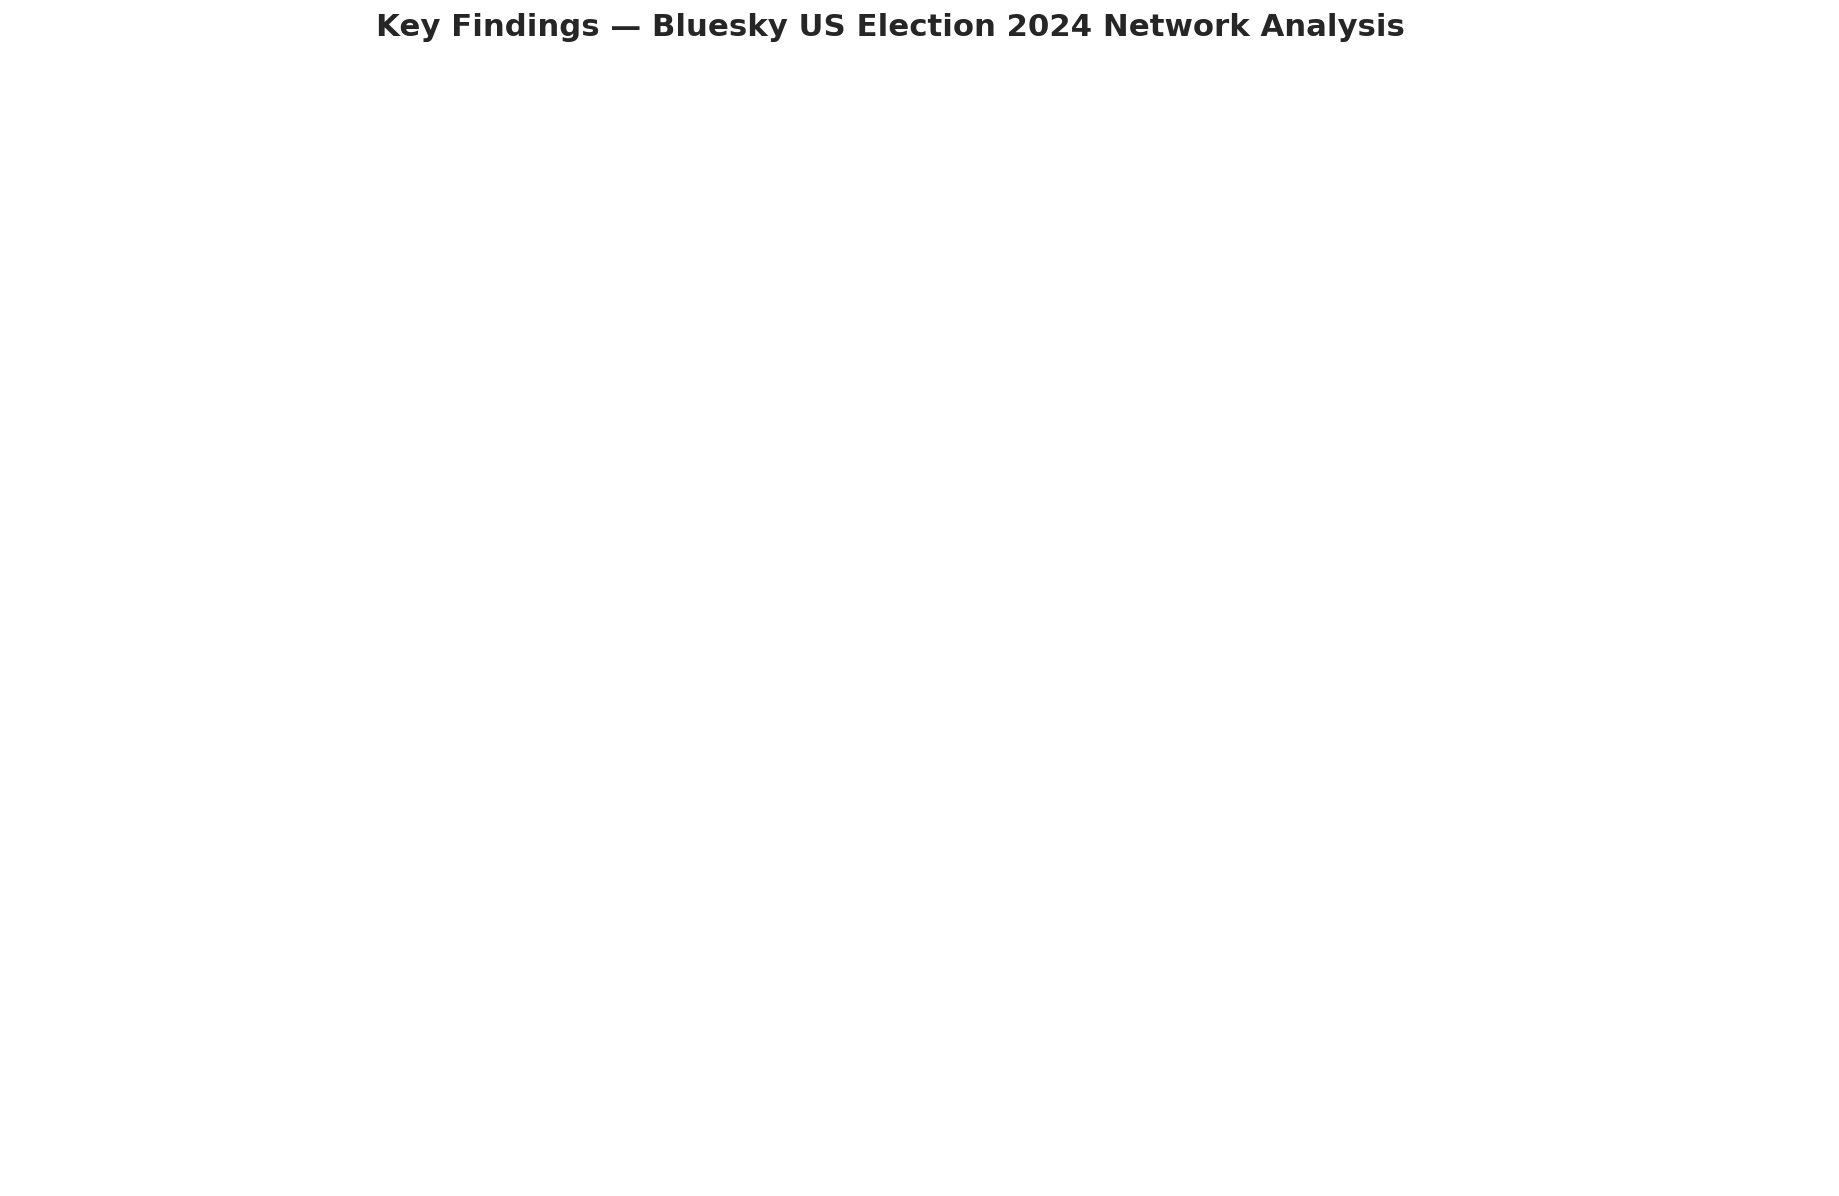

Figure saved: data/fig_key_findings.png


In [141]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 7 — Key Findings Dashboard (presentation-ready)
# ═══════════════════════════════════════════════════════════════════════════════
top_influencer  = author_stats.iloc[0]
top_handle      = top_influencer["author"].replace(".bsky.social","").replace(".com","").replace(".gay","")
harris_pct      = (df["candidate"]=="CandidateB").mean() * 100
election_day_n  = df[df["date"]==pd.Timestamp("2024-11-05")].shape[0]
pre_election_avg= df[df["date"]<pd.Timestamp("2024-11-05")].groupby("date").size().mean()

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── KPI cards ────────────────────────────────────────────────────────────────
kpis = [
    (f"{len(df):,}",                    "Posts collected",                           GOLD),
    (f"{df['author'].nunique():,}",      "Unique accounts",                           BLUE),
    (f"{df['engagement'].sum():,}",      "Total engagement",                          "#27AE60"),
    (f"@{top_handle}",                   f"Top influencer\n({top_influencer['total_eng']} eng.)", RED),
    (f"{harris_pct:.0f}%",              "Harris-leaning posts",                      BLUE),
    (f"{election_day_n}x",              f"Election-day spike\nvs avg {pre_election_avg:.0f}/day", "#8E44AD"),
]
for idx, (val, label, color) in enumerate(kpis):
    row, col = divmod(idx, 3)
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor(color)
    ax.text(0.5, 0.58, val,   ha="center", va="center", fontsize=28,
            fontweight="bold", color="white", transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha="center", va="center", fontsize=11,
            color="white", transform=ax.transAxes, alpha=0.92)
    ax.axis("off")

fig.suptitle("Key Findings — Bluesky US Election 2024 Network Analysis",
             fontsize=17, fontweight="bold", y=1.01)
plt.savefig("data/fig_key_findings.png", bbox_inches="tight", dpi=200)
plt.show()
print("Figure saved: data/fig_key_findings.png")


---
### Conclusions

**1. Bluesky is strongly left-leaning for this election**
- 35% of posts lean Harris, 11% lean Trump, 54% neutral
- Harris posts generate more total engagement (2,809 vs 1,040)

**2. Virality beats volume**
- Top influencer `@johnfugelsang` scored 597 engagement from **1 post**
- The most prolific poster (`@kenserlore96`, 16 posts) scored only 249
- *One high-quality, emotionally resonant post > 16 average posts*

**3. Massive election-day spike**
- Election Day (Nov 5): **524 posts** vs average of ~18/day beforehand
- This 29× spike mirrors real-world event-driven social media behaviour

**4. Network structure**
- The mention network has **low density** — most accounts post independently
- KamalaHarris is the most mentioned account (6×) — direct evidence of mobilisation
- Community modularity Q indicates moderate echo-chamber formation

**5. Implication for Polymarket**
- High-engagement Harris-leaning accounts could shift sentiment-based prediction markets
- Trump supporters are nearly absent from Bluesky — platform selection bias is significant
